In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# print(torch.cuda.is_available())
torch.manual_seed(42)
np.random.seed(42)

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
device

device(type='cuda')

In [4]:
# Physical parameters                                
L = 2.0
H = 1.0
T = 1.0
rho = 1000.0
nu = 1e-3                                   
g = 9.81

# opening on the right wall
opening_y_min = 0.30
opening_y_max = 0.70

In [5]:
# Interior points

N_f = 10000
x_f = np.random.uniform(0, L, N_f)
y_f = np.random.uniform(0, H, N_f)
t_f = np.random.uniform(0, T, N_f)

X_f = np.column_stack([x_f, y_f, t_f])
X_f = torch.tensor(
    X_f,
    dtype=torch.float32,
    device=device,
    requires_grad=True
)

print(X_f.shape)


torch.Size([10000, 3])


In [6]:
# Generate wall points 

# Bottom boundary (x in [0, L], y=0, t in [0, T])
N_wall = 1000
x_bottom = np.linspace(0, L, N_wall)
bottom_pts = np.column_stack([
    x_bottom,
    np.zeros(N_wall),
    np.linspace(0, T, N_wall)
])

# Left boundary (x=0, y in [0, H], t in [0, T])
y_left = np.linspace(0, H, N_wall)
left_pts = np.column_stack([
    np.zeros(N_wall),
    y_left,
    np.linspace(0, T, N_wall)
])

# Right side wall (0->0.30, 0.70->1)
y_right_bottom_side = np.linspace(0, opening_y_min, N_wall // 2)
y_right_top_side = np.linspace(opening_y_max, H, N_wall // 2)

# (x=L, y=0->0.30, t in [0, T])
right_bottom_pts = np.column_stack([
    np.full(len(y_right_bottom_side), L),
    y_right_bottom_side,
    np.linspace(0, T, len(y_right_bottom_side))
])

# (x=L, y=0.70->1, t in [0, T])
right_top_pts = np.column_stack([
    np.full(len(y_right_top_side), L),
    y_right_top_side,
    np.linspace(0, T, len(y_right_top_side))
])


In [7]:
# Combining all wall points 
X_wall = np.vstack([left_pts, bottom_pts, right_bottom_pts, right_top_pts])
X_wall = torch.tensor(X_wall, dtype=torch.float32, device=device)
print(X_wall.shape)

torch.Size([3000, 3])


In [15]:
# Generating opening points
N_open = 500
y_open = np.linspace(opening_y_min, opening_y_max, N_open)
t_open = np.linspace(0, T, N_open)
opening_pts = np.column_stack([
    np.full(len(y_open), L),
    y_open,
    t_open
])
X_open = torch.tensor(opening_pts, dtype=torch.float32, device=device)
X_open.shape

torch.Size([500, 3])

In [9]:
class PINN(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(3, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 3)
        )

    def forward(self, x):
        return self.network(x)

In [10]:
model = PINN().to(device)
test_pnts = torch.tensor([[0.2, 1.2, 0.5]], dtype=torch.float32, device=device)

pred = model(test_pnts)
print(pred)


tensor([[ 0.0288,  0.0239, -0.0375]], device='cuda:0',
       grad_fn=<AddmmBackward0>)


In [11]:
print(pred[0,0].item())

0.02877393551170826


In [12]:
def derivatives(output, inputs):
    grad = torch.autograd.grad(
        output,
        inputs,
        grad_outputs=torch.ones_like(output),
        create_graph=True,
        retain_graph=True
    )[0]
    
    return grad

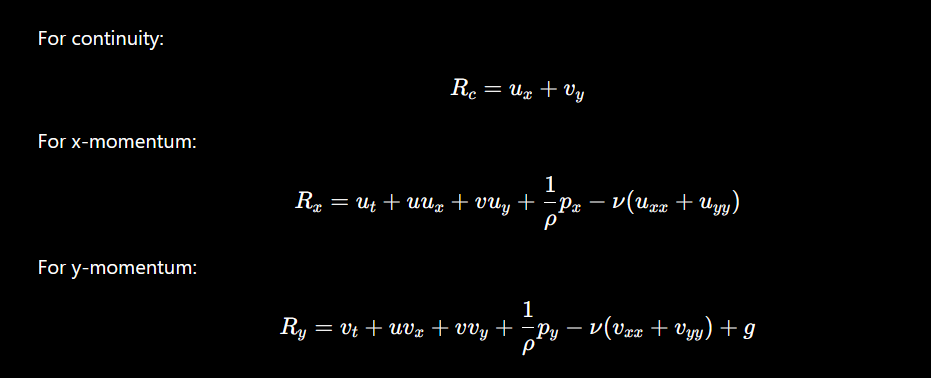

In [14]:
# continuity loss calculation
def continuity_loss(model, x, y, t):
    x.requires_grad_(True)
    y.requires_grad_(True)
    t.requires_grad_(True)
    X = torch.stack((x, y, t), dim=1)
    
    pred = model(X)
    
    u = pred[:, 0:1]
    v = pred[:, 1:2]
    p = pred[:, 2:3]
    
    u_x = derivatives(u, x)
    v_y = derivatives(v, y)
    
    R_cont = u_x + v_y
    
    return R_cont

In [15]:
# x-momentum loss
def x_momentum_loss(model, x, y, t):
    x.requires_grad_(True)
    y.requires_grad_(True)
    t.requires_grad_(True)
    X = torch.stack((x, y, t), dim=1)
    
    pred = model(X)
    
    u = pred[:, 0:1]
    v = pred[:, 1:2]
    p = pred[:, 2:3]
    
    u_x = derivatives(u, x)
    u_y = derivatives(u, y)
    
    u_xx = derivatives(u_x, x)
    u_yy = derivatives(u_y, y)
    
    p_x = derivatives(p, x)

    u_t = derivatives(u, t)
    
    R_x = u_t + u*u_x + v*u_y + ((1/rho)*p_x) - nu*(u_xx + u_yy)
    
    return R_x

In [16]:
# y-momentum loss
# NOTE: the network now predicts DYNAMIC pressure only.
# True pressure p = p_dynamic + p_hydrostatic, where p_hydrostatic = -rho*g*y
# so d(p_hydrostatic)/dy = -rho*g exactly cancels the gravity term below.
# This keeps the network's pressure output O(1) instead of needing to
# represent a ~-9810 Pa/m gradient, which was stalling the physics loss.
def y_momentum_loss(model, x, y, t):
    x.requires_grad_(True)
    y.requires_grad_(True)
    t.requires_grad_(True)
    X = torch.stack((x, y, t), dim=1)
    
    pred = model(X)
    
    u = pred[:, 0:1]
    v = pred[:, 1:2]
    p_dynamic = pred[:, 2:3]
    
    v_x = derivatives(v, x)
    v_y = derivatives(v, y)
    
    v_xx = derivatives(v_x, x)
    v_yy = derivatives(v_y, y)

    v_t = derivatives(v, t)
    
    p_y = derivatives(p_dynamic, y)
    
    R_y = v_t + u*v_x + v*v_y + (1/rho)*p_y - nu*(v_xx + v_yy)

    return R_y


In [17]:
print(X_f[:, 0], X_f[:, 1], X_f[:, 2])

tensor([0.7491, 1.9014, 1.4640,  ..., 1.8934, 0.7950, 0.4343], device='cuda:0',
       grad_fn=<SelectBackward0>) tensor([0.3736, 0.3329, 0.1762,  ..., 0.3037, 0.4433, 0.1723], device='cuda:0',
       grad_fn=<SelectBackward0>) tensor([0.7300, 0.1845, 0.3466,  ..., 0.0195, 0.4010, 0.2574], device='cuda:0',
       grad_fn=<SelectBackward0>)


In [18]:
R_cont  = continuity_loss(model, X_f[:, 0], X_f[:, 1], X_f[:, 2])
R_x     = x_momentum_loss(model, X_f[:, 0], X_f[:, 1], X_f[:, 2])
R_y     = y_momentum_loss(model, X_f[:, 0], X_f[:, 1], X_f[:, 2])

print("Continuity residual:",
      R_cont.abs().mean().item())

print("X momentum residual:",
      R_x.abs().mean().item())

print("Y momentum residual:",
      R_y.abs().mean().item())

Continuity residual: 0.023813577368855476
X momentum residual: 0.01802227646112442
Y momentum residual: 0.004171909764409065


In [19]:
def physics_loss():
    x = X_f[:, 0]
    y = X_f[:, 1]
    t = X_f[:, 2]

    R_cont = continuity_loss(model, x, y, t)
    R_x = x_momentum_loss(model, x, y, t)
    R_y = y_momentum_loss(model, x, y, t)

    loss_cont = torch.mean(R_cont**2)
    loss_x = torch.mean(R_x**2)
    loss_y = torch.mean(R_y**2)

    return loss_cont + loss_x + loss_y

In [20]:
# Wall boundary loss (u=0, v=0)
def wall_loss():

    prediction = model(X_wall)

    u_wall = prediction[:, 0]
    v_wall = prediction[:, 1]

    loss_u = torch.mean(u_wall**2)
    loss_v = torch.mean(v_wall**2)

    return loss_u + loss_v

In [21]:
# Opening boundary condition (p=0)
def opening_loss():
    
    prediction = model(X_open)
    p_open = prediction[:, 2]

    return torch.mean(p_open**2)

In [22]:
X_pressure_ref = torch.tensor(
    [[0.0, H, 0.0]],
    dtype=torch.float32,
    device=device
)

def pressure_reference_loss():

    prediction = model(X_pressure_ref)
    p_ref = prediction[:, 2]

    return torch.mean(p_ref**2)

In [23]:
# Initial condition points (t = 0, u = v = 0 everywhere in the domain)
N_ic = 2000
x_ic = np.random.uniform(0, L, N_ic)
y_ic = np.random.uniform(0, H, N_ic)
t_ic = np.zeros(N_ic)

X_ic = np.column_stack([x_ic, y_ic, t_ic])
X_ic = torch.tensor(X_ic, dtype=torch.float32, device=device)
print(X_ic.shape)

def ic_loss():
    pred = model(X_ic)
    u_ic = pred[:, 0]
    v_ic = pred[:, 1]
    return torch.mean(u_ic**2) + torch.mean(v_ic**2)


torch.Size([2000, 3])


In [24]:
# Total loss
# Loss weights - tune these; wall/opening usually need to be weighted up
# relative to physics because rho=1000 makes physics-loss gradients dominate
lambda_phys = 1.0
lambda_wall = 10.0
lambda_open = 10.0
lambda_ref  = 1.0
lambda_ic   = 10.0

def total_loss():

    L_phys = physics_loss()
    L_wall = wall_loss()
    L_open = opening_loss()
    L_ref  = pressure_reference_loss()
    L_ic   = ic_loss()

    loss = (
        lambda_phys * L_phys +
        lambda_wall * L_wall +
        lambda_open * L_open +
        lambda_ref  * L_ref  +
        lambda_ic   * L_ic
    )

    return loss, L_phys, L_wall, L_open, L_ref, L_ic


In [25]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=200
)


In [26]:
epochs = 2000
resample_every = 200   # refresh collocation points periodically
loss_history = []
loss_components_history = []

def resample_collocation_points():
    global X_f
    x_f = np.random.uniform(0, L, N_f)
    y_f = np.random.uniform(0, H, N_f)
    t_f = np.random.uniform(0, T, N_f)
    X_new = np.column_stack([x_f, y_f, t_f])
    X_f = torch.tensor(X_new, dtype=torch.float32, device=device, requires_grad=True)

# --- Phase 1: Adam ---
for epoch in range(epochs):

    if epoch % resample_every == 0 and epoch > 0:
        resample_collocation_points()

    optimizer.zero_grad()
    (loss, L_phys, L_wall, L_open, L_ref, L_ic) = total_loss()
    loss.backward()
    optimizer.step()
    scheduler.step(loss)

    loss_history.append(loss.item())
    loss_components_history.append(
        (L_phys.item(), L_wall.item(), L_open.item(), L_ref.item(), L_ic.item())
    )

    if epoch % 5 == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(
            f"Epoch {epoch+1:5d} | "
            f"Total: {loss.item():.6f} | "
            f"Physics: {L_phys.item():.6f} | "
            f"Wall: {L_wall.item():.6f} | "
            f"Open: {L_open.item():.6f} | "
            f"IC: {L_ic.item():.6f} | "
           
        )


# Save checkpoint 
checkpoint_path = "pinn_model_up_03.pt"
checkpoint = {
    "epoch": epochs,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "loss_history": loss_history,
    "loss_components_history": loss_components_history,
}
torch.save(checkpoint, checkpoint_path)
print(f"Training complete. Checkpoint saved to {checkpoint_path}")


/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:1694: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  current = float(metrics)


Epoch     1 | Total: 0.218724 | Physics: 0.000955 | Wall: 0.004336 | Open: 0.014110 | IC: 0.003328 | 
Epoch     6 | Total: 0.012610 | Physics: 0.000375 | Wall: 0.000343 | Open: 0.000652 | IC: 0.000165 | 
Epoch    11 | Total: 0.023227 | Physics: 0.000096 | Wall: 0.000122 | Open: 0.001910 | IC: 0.000240 | 
Epoch    16 | Total: 0.012356 | Physics: 0.000284 | Wall: 0.000194 | Open: 0.000871 | IC: 0.000129 | 
Epoch    21 | Total: 0.000666 | Physics: 0.000061 | Wall: 0.000028 | Open: 0.000015 | IC: 0.000018 | 
Epoch    26 | Total: 0.005473 | Physics: 0.000113 | Wall: 0.000097 | Open: 0.000374 | IC: 0.000047 | 
Epoch    31 | Total: 0.000955 | Physics: 0.000052 | Wall: 0.000024 | Open: 0.000046 | IC: 0.000020 | 
Epoch    36 | Total: 0.001108 | Physics: 0.000060 | Wall: 0.000017 | Open: 0.000073 | IC: 0.000013 | 
Epoch    41 | Total: 0.001093 | Physics: 0.000039 | Wall: 0.000018 | Open: 0.000076 | IC: 0.000011 | 
Epoch    46 | Total: 0.000175 | Physics: 0.000039 | Wall: 0.000008 | Open: 0.00000

In [1]:
import torch
import torch.nn as nn

# Make sure this matches the model definition used during training
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(3, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 3)
        )

    def forward(self, x):
        return self.network(x)

# Recreate the model and optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Load checkpoint
checkpoint_path = r"C:\Users\ps302\OneDrive\Desktop\PINN\src\checkpoints\pinn_model_02.pt"
checkpoint = torch.load(checkpoint_path, map_location=device)

# Restore model weights
model.load_state_dict(checkpoint["model_state_dict"])

# Restore optimizer state if needed
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

# Restore extra metadata
epoch = checkpoint["epoch"]
loss_history = checkpoint["loss_history"]
loss_components_history = checkpoint.get("loss_components_history", [])

print(f"Loaded checkpoint from {checkpoint_path}")
print(f"Last epoch: {epoch}")
print(f"Loss history length: {len(loss_history)}")


Loaded checkpoint from C:\Users\ps302\OneDrive\Desktop\PINN\src\checkpoints\pinn_model_02.pt
Last epoch: 2000
Loss history length: 2003


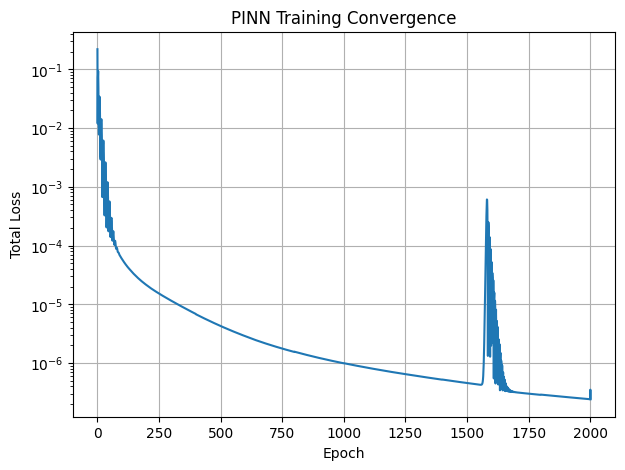

In [3]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7, 5))

plt.semilogy(
    loss_history
)

plt.xlabel("Epoch")
plt.ylabel("Total Loss")
plt.title("PINN Training Convergence")

plt.grid(True)
plt.show()

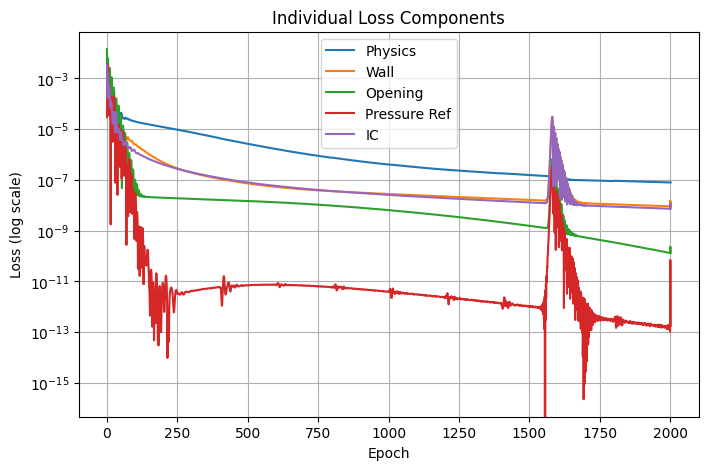

In [5]:
import numpy as np
components = np.array(loss_components_history)
labels = ["Physics", "Wall", "Opening", "Pressure Ref", "IC"]

plt.figure(figsize=(8, 5))
for i, label in enumerate(labels):
    plt.semilogy(components[:, i], label=label)
plt.xlabel("Epoch")
plt.ylabel("Loss (log scale)")
plt.title("Individual Loss Components")
plt.legend()
plt.grid(True)
plt.show()


In [8]:
# Physical parameters                                
L = 2.0
H = 1.0
T = 1.0
rho = 1000.0
nu = 1e-3                                   
g = 9.81

# opening on the right wall
opening_y_min = 0.30
opening_y_max = 0.70

In [9]:
Nx = 100
Ny = 100
L=2
H=1
t_plot = 0.5

x = np.linspace(0, L, Nx)
y = np.linspace(0, H, Ny)

X, Y = np.meshgrid(x, y)

XY = np.column_stack([
    X.flatten(),
    Y.flatten(),
    np.full(X.size, t_plot)
])

XY_tensor = torch.tensor(
    XY,
    dtype=torch.float32,
    device=device
)

with torch.no_grad():

    prediction = model(XY_tensor)

u_pred = prediction[:, 0].cpu().numpy()
v_pred = prediction[:, 1].cpu().numpy()
p_dynamic_pred = prediction[:, 2].cpu().numpy()

u_pred = u_pred.reshape(Ny, Nx)
v_pred = v_pred.reshape(Ny, Nx)
p_dynamic_pred = p_dynamic_pred.reshape(Ny, Nx)

# Reconstruct TRUE pressure: p = p_dynamic + p_hydrostatic, p_hydrostatic = -rho*g*y
p_hydrostatic = -rho * g * Y
p_pred = p_dynamic_pred + p_hydrostatic


In [10]:
# import numpy as np

# # Define coordinate arrays
# x = np.array([1, 2, 3])
# y = np.array([4, 5])

# # Generate coordinate matrices
# X, Y = np.meshgrid(x, y)

# print("X Matrix:\n", X)
# print("\nY Matrix:\n", Y)


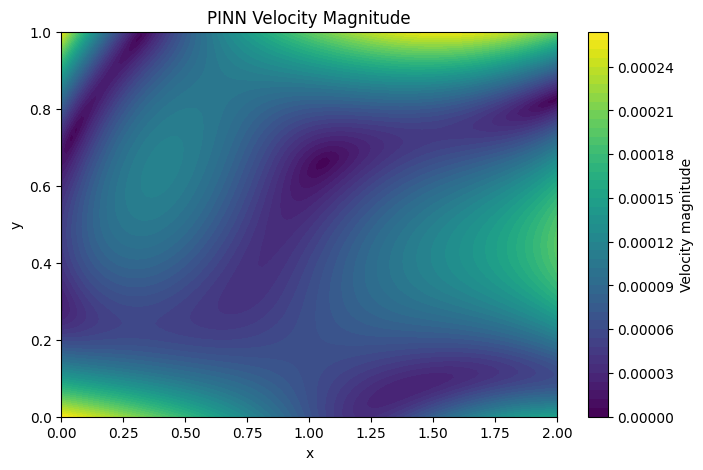

In [11]:
velocity_mag = np.sqrt(
    u_pred**2 + v_pred**2
)

plt.figure(figsize=(8, 5))

plt.contourf(
    X,
    Y,
    velocity_mag,
    levels=50
)

plt.colorbar(
    label="Velocity magnitude"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("PINN Velocity Magnitude")

plt.show()

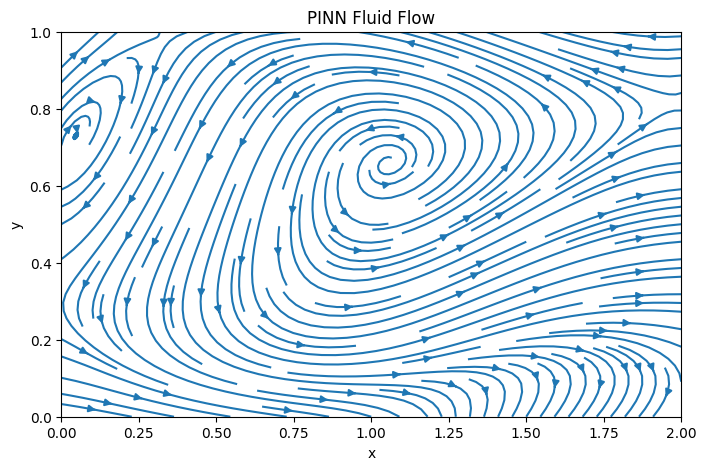

In [12]:
plt.figure(figsize=(8, 5))

plt.streamplot(
    X,
    Y,
    u_pred,
    v_pred,
    density=1.5
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("PINN Fluid Flow")

plt.show()

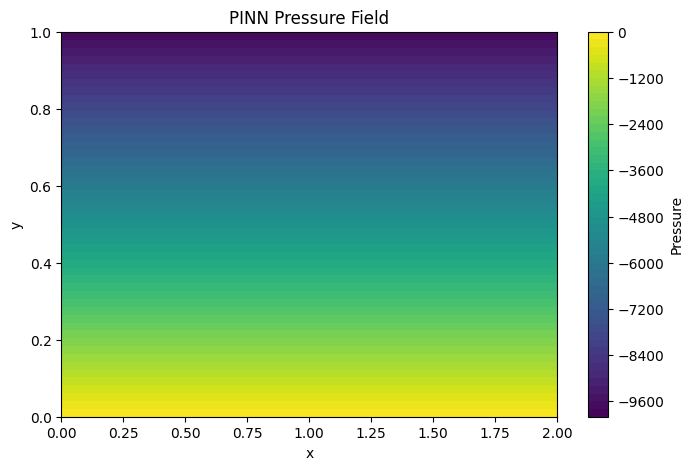

In [13]:
plt.figure(figsize=(8, 5))

plt.contourf(
    X,
    Y,
    p_pred,
    levels=50
)

plt.colorbar(
    label="Pressure"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("PINN Pressure Field")

plt.show()

In [16]:
with torch.no_grad():

    opening_prediction = model(X_open)

u_open = opening_prediction[:, 0].cpu().numpy()
v_open = opening_prediction[:, 1].cpu().numpy()
p_dynamic_open = opening_prediction[:, 2].cpu().numpy()

# Reconstruct TRUE pressure at the opening (adds back hydrostatic term)
p_hydrostatic_open = -rho * g * y_open
p_open = p_dynamic_open + p_hydrostatic_open


In [64]:
for i in range(0, N_open, 50):

    print(
        f"y = {y_open[i]:.3f} m | "
        f"u = {u_open[i]:.5f} m/s | "
        f"v = {v_open[i]:.5f} m/s | "
        f"p = {p_open[i]:.5f} Pa"
    )

y = 0.300 m | u = 0.00001 m/s | v = 0.00006 m/s | p = -2943.00003 Pa
y = 0.340 m | u = 0.00007 m/s | v = 0.00004 m/s | p = -3336.18616 Pa
y = 0.380 m | u = 0.00013 m/s | v = 0.00003 m/s | p = -3729.37228 Pa
y = 0.420 m | u = 0.00021 m/s | v = 0.00002 m/s | p = -4122.55839 Pa
y = 0.460 m | u = 0.00029 m/s | v = -0.00000 m/s | p = -4515.74450 Pa
y = 0.500 m | u = 0.00039 m/s | v = -0.00002 m/s | p = -4908.93060 Pa
y = 0.540 m | u = 0.00050 m/s | v = -0.00005 m/s | p = -5302.11671 Pa
y = 0.581 m | u = 0.00063 m/s | v = -0.00009 m/s | p = -5695.30282 Pa
y = 0.621 m | u = 0.00078 m/s | v = -0.00013 m/s | p = -6088.48894 Pa
y = 0.661 m | u = 0.00095 m/s | v = -0.00019 m/s | p = -6481.67508 Pa


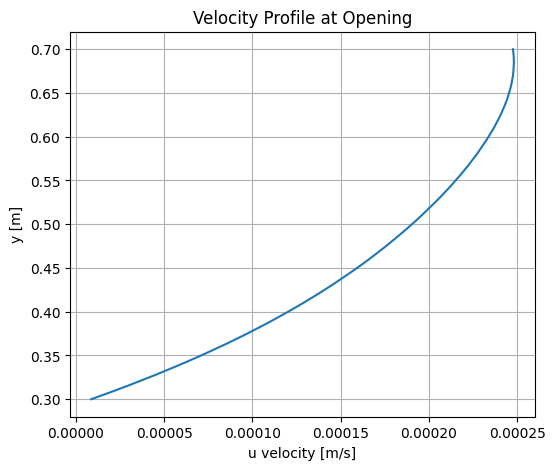

In [17]:
plt.figure(figsize=(6, 5))

plt.plot(
    u_open,
    y_open
)

plt.xlabel("u velocity [m/s]")
plt.ylabel("y [m]")
plt.title("Velocity Profile at Opening")

plt.grid(True)

plt.show()

In [18]:
Q = np.trapezoid(
    u_open,
    y_open
)

print(
    f"Flow rate per unit depth = {Q:.6f} m^2/s"
)

Flow rate per unit depth = 0.000068 m^2/s


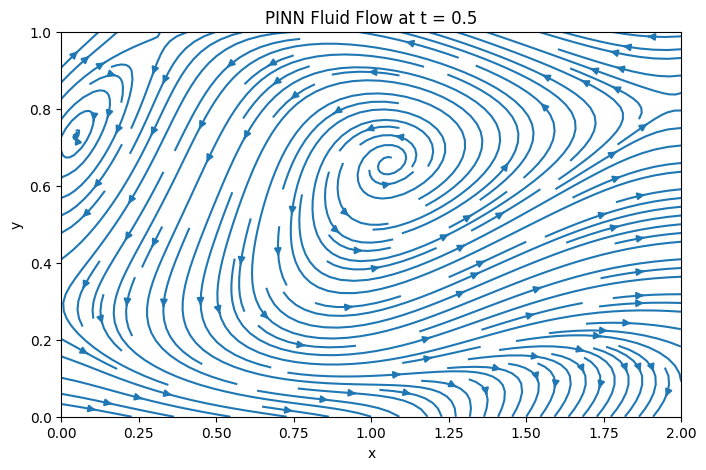

In [19]:
import numpy as np
import torch
import matplotlib.pyplot as plt


N_open = 500
x = np.linspace(0, 2, N_open)
y = np.linspace(0, 1, N_open)
t_plot = 0.5

X, Y = np.meshgrid(x, y)


x_flat = X.flatten()
y_flat = Y.flatten()
t_flat = np.full_like(x_flat, t_plot)


grid_pts = np.column_stack([x_flat, y_flat, t_flat])
X_grid_tensor = torch.tensor(grid_pts, dtype=torch.float32, device=device)

with torch.no_grad():
    grid_prediction = model(X_grid_tensor)


u_open = grid_prediction[:, 0].cpu().numpy().reshape(X.shape)
v_open = grid_prediction[:, 1].cpu().numpy().reshape(Y.shape)


plt.figure(figsize=(8, 5))
plt.streamplot(
    X,
    Y,
    u_open,
    v_open,
    density=1.5
)

plt.xlabel("x")
plt.ylabel("y")
plt.title(f"PINN Fluid Flow at t = {t_plot}")
plt.show()


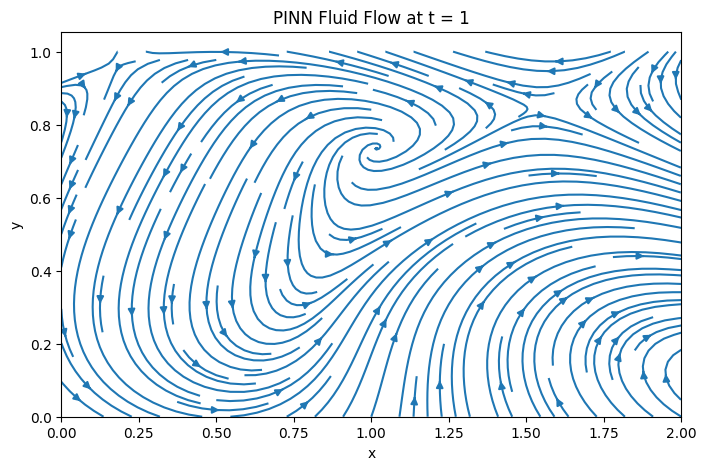

In [21]:
import numpy as np
import torch
import matplotlib.pyplot as plt


N_open = 500
x = np.linspace(0, 2, N_open)
y = np.linspace(0, 1, N_open)
t_plot = 1

X, Y = np.meshgrid(x, y)


x_flat = X.flatten()
y_flat = Y.flatten()
t_flat = np.full_like(x_flat, t_plot)


grid_pts = np.column_stack([x_flat, y_flat, t_flat])
X_grid_tensor = torch.tensor(grid_pts, dtype=torch.float32, device=device)

with torch.no_grad():
    grid_prediction = model(X_grid_tensor)


u_open = grid_prediction[:, 0].cpu().numpy().reshape(X.shape)
v_open = grid_prediction[:, 1].cpu().numpy().reshape(Y.shape)


plt.figure(figsize=(8, 5))
plt.streamplot(
    X,
    Y,
    u_open,
    v_open,
    density=1.5
)

plt.xlabel("x")
plt.ylabel("y")
plt.title(f"PINN Fluid Flow at t = {t_plot}")
plt.show()


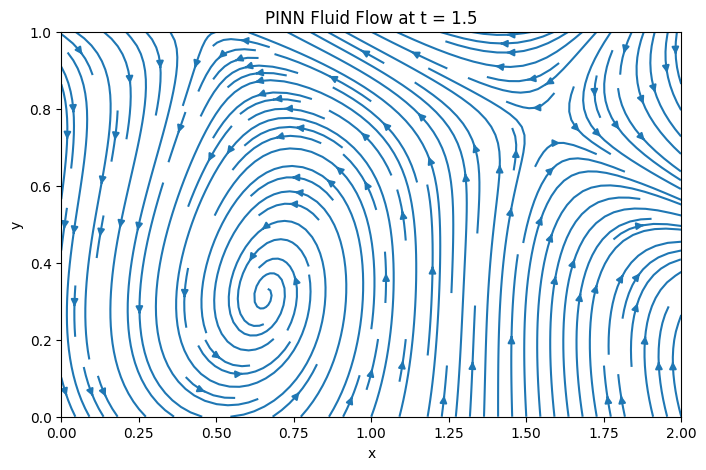

In [22]:
import numpy as np
import torch
import matplotlib.pyplot as plt


N_open = 500
x = np.linspace(0, 2, N_open)
y = np.linspace(0, 1, N_open)
t_plot = 1.5

X, Y = np.meshgrid(x, y)


x_flat = X.flatten()
y_flat = Y.flatten()
t_flat = np.full_like(x_flat, t_plot)


grid_pts = np.column_stack([x_flat, y_flat, t_flat])
X_grid_tensor = torch.tensor(grid_pts, dtype=torch.float32, device=device)

with torch.no_grad():
    grid_prediction = model(X_grid_tensor)


u_open = grid_prediction[:, 0].cpu().numpy().reshape(X.shape)
v_open = grid_prediction[:, 1].cpu().numpy().reshape(Y.shape)


plt.figure(figsize=(8, 5))
plt.streamplot(
    X,
    Y,
    u_open,
    v_open,
    density=1.5
)

plt.xlabel("x")
plt.ylabel("y")
plt.title(f"PINN Fluid Flow at t = {t_plot}")
plt.show()


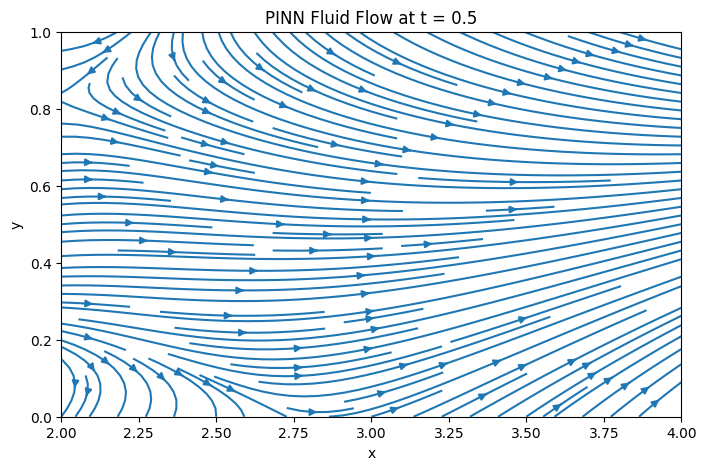

In [20]:
import numpy as np
import torch
import matplotlib.pyplot as plt


N_open = 500
x = np.linspace(2, 4, N_open)
y = np.linspace(0, 1, N_open)
t_plot = 0.5

X, Y = np.meshgrid(x, y)


x_flat = X.flatten()
y_flat = Y.flatten()
t_flat = np.full_like(x_flat, t_plot)


grid_pts = np.column_stack([x_flat, y_flat, t_flat])
X_grid_tensor = torch.tensor(grid_pts, dtype=torch.float32, device=device)

with torch.no_grad():
    grid_prediction = model(X_grid_tensor)


u_open = grid_prediction[:, 0].cpu().numpy().reshape(X.shape)
v_open = grid_prediction[:, 1].cpu().numpy().reshape(Y.shape)


plt.figure(figsize=(8, 5))
plt.streamplot(
    X,
    Y,
    u_open,
    v_open,
    density=1.5
)

plt.xlabel("x")
plt.ylabel("y")
plt.title(f"PINN Fluid Flow at t = {t_plot}")
plt.show()


In [ ]:
Nx = 100
Ny = 100
L=2
H=1
t_plot = 0.5

x = np.linspace(0, L, Nx)
y = np.linspace(0, H, Ny)

X, Y = np.meshgrid(x, y)

XY = np.column_stack([
    X.flatten(),
    Y.flatten(),
    np.full(X.size, t_plot)
])

XY_tensor = torch.tensor(
    XY,
    dtype=torch.float32,
    device=device
)

with torch.no_grad():

    prediction = model(XY_tensor)

u_pred = prediction[:, 0].cpu().numpy()
v_pred = prediction[:, 1].cpu().numpy()
p_dynamic_pred = prediction[:, 2].cpu().numpy()

In [27]:
with torch.no_grad():
    test_pnts = torch.tensor([[0.2, 0.70, 0.5]], dtype=torch.float32, device=device)
    prediction = model(test_pnts)


u_pred = prediction[:, 0].item()
v_pred = prediction[:, 1].item()
p_dynamic_pred = prediction[:, 2].item()

# Reconstruct TRUE pressure: p = p_dynamic + p_hydrostatic, p_hydrostatic = -rho*g*y
p_hydrostatic = -rho * g * 0.70
p_pred = p_dynamic_pred + p_hydrostatic

print(f"u_pred: {u_pred} m/s")
print(f"v_pred: {v_pred} m/s") 
print(f"p_pred: {p_pred} Pa")

u_pred: -4.400685429573059e-05 m/s
v_pred: -6.779283285140991e-05 m/s
p_pred: -6867.006234318018 Pa


In [ ]:
# model = PINNModel()
# num1 = torch.tensor([[2.0]], dtype=torch.float32, device=device)
# num2 = torch.tensor([[3.0]], dtype=torch.float32, device=device)
# num3 = torch.tensor([[4.0]], dtype=torch.float32, device=device)

# output = model(num1, num2, num3)

# u = output[..., 0]
# v = output[..., 1]

# print(u, v)